<div style="text-align:center;">
  <h1 size=10>
    <b>BIG DATA ANALYTICS PROJECT</b><br>
    <b>Baldness Classification</b>
  </h1>
</div>

<h2 style="text-align:center;">
Master's in Data Science and Advanced Analytics - NOVA IMS (25/26)
</h2>

**Group 26**
- Bárbara Franco (20250388)
- Catarina Mendinhas (20250422)
- Maria Miguel Fonseca (20250380)
- Rodrigo Santos (20250387)
- Rodrigo Teixeira (20250393)

**GitHub repository:**

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Set Up & Import Libraries](#2)
- [3. Load Data](#3)
- [4. Data Exploration](#4)
- [5. Data Exploration](#5)
- [6. Undersampling](#6)


# <font color='#2f94d7' size=6>**1. Project Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

# <font color='#2f94d7' size=6>**2. Set Up & Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [1]:
!pip install pyspark

In [2]:
# IMPORT LIBRARIES
import random
import os
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType

In [3]:
# Install Java 17 (Required for Spark)
!sudo apt-get update
!sudo apt-get install -y openjdk-17-jdk-headless
!java -version

Hit:1 https://packages.cloud.google.com/apt cloud-sdk InRelease
Get:2 https://cli.github.com/packages stable InRelease [3917 B]                
Hit:3 https://download.docker.com/linux/ubuntu noble InRelease                 
Hit:4 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease          
Hit:5 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease  
Hit:6 https://security.ubuntu.com/ubuntu noble-security InRelease              
Hit:7 http://deb.wakemeops.com/wakemeops stable InRelease                      
Hit:8 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:9 https://archive.ubuntu.com/ubuntu noble InRelease             
Hit:10 https://cloud.archive.ubuntu.com/ubuntu noble InRelease
Hit:11 https://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:12 https://cloud.archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:13 https://archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:14 https://cloud.archive.ubuntu.com/u

In [4]:
# Set JAVA_HOME and initialize Spark Session with specific configurations
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("BaldClassification")
    .config("spark.driver.memory", "12g") # RAM for the driven
    .config("spark.sql.files.maxPartitionBytes", "128m")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/13 16:56:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


In [5]:
# DEFINE DATA PATHS
BASE_PATH = "data/Data_Bald_People" 
SPLITS    = ["Train", "Validation", "Test"]
LABELS    = ["Bald", "NotBald"]

In [6]:
# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# <font color='#2f94d7' size=6>**3. Load Data**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

In [7]:
dfs = []

for split in SPLITS:
    for label in LABELS:
        folder = os.path.join(BASE_PATH, split, label)

        df_part = (
            spark.read.format("binaryFile")
            .option("pathGlobFilter", "*.jpg")   # muda para *.png se necessário
            .option("recursiveFileLookup", "false")
            .load(folder)
            .select(
                F.col("path"),
                F.col("content"),
                F.col("length").alias("file_size_bytes"),
            )
            .withColumn("label",          F.lit(label))
            .withColumn("label_index",    F.lit(1 if label == "Bald" else 0).cast("integer"))
            .withColumn("original_split", F.lit(split))
        )

        dfs.append(df_part)
        print(f"  Loaded {split}/{label}")

df_all = dfs[0]
for df in dfs[1:]:
    df_all = df_all.union(df)

#df_all.cache()
print(f"\nTotal images loaded: {df_all.count():,}")

  Loaded Train/Bald


26/05/13 16:57:02 WARN SharedInMemoryCache: Evicting cached table partition metadata from memory due to size constraints (spark.sql.hive.filesourcePartitionFileCacheSize = 262144000 bytes). This may impact query planning performance.


  Loaded Train/NotBald
  Loaded Validation/Bald
  Loaded Validation/NotBald
  Loaded Test/Bald
  Loaded Test/NotBald



Total images loaded: 202,599


# <font color='#2f94d7' size=6>**4. Data Exploration**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

In [8]:
# ! pip install "pandas>=2.2.0" --upgrade

In [9]:
df_meta = df_all.drop("content")
df_meta.createOrReplaceTempView("image_metadata")

# Distribuição por split e label
df_dist = spark.sql("""
    SELECT original_split, label, COUNT(*) AS n_images
    FROM image_metadata
    GROUP BY original_split, label
    ORDER BY original_split, label
""")
df_dist.show()


class_counts = (
    df_dist.groupBy("label")
    .agg(F.sum("n_images").alias("n"))
    .toPandas()
)

n_bald    = int(class_counts.loc[class_counts.label == "Bald",    "n"].values[0])
n_notbald = int(class_counts.loc[class_counts.label == "NotBald", "n"].values[0])
print(f"Bald    : {n_bald:,}")
print(f"NotBald : {n_notbald:,}")
print(f"Imbalance ratio: {round(max(n_bald, n_notbald) / min(n_bald, n_notbald), 2)}x")

+--------------+-------+--------+
|original_split|  label|n_images|
+--------------+-------+--------+
|          Test|   Bald|     421|
|          Test|NotBald|   19579|
|         Train|   Bald|    3656|
|         Train|NotBald|  156344|
|    Validation|   Bald|     470|
|    Validation|NotBald|   22129|
+--------------+-------+--------+



Bald    : 4,547
NotBald : 198,052
Imbalance ratio: 43.56x


/tmp/ipykernel_53355/2680140956.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


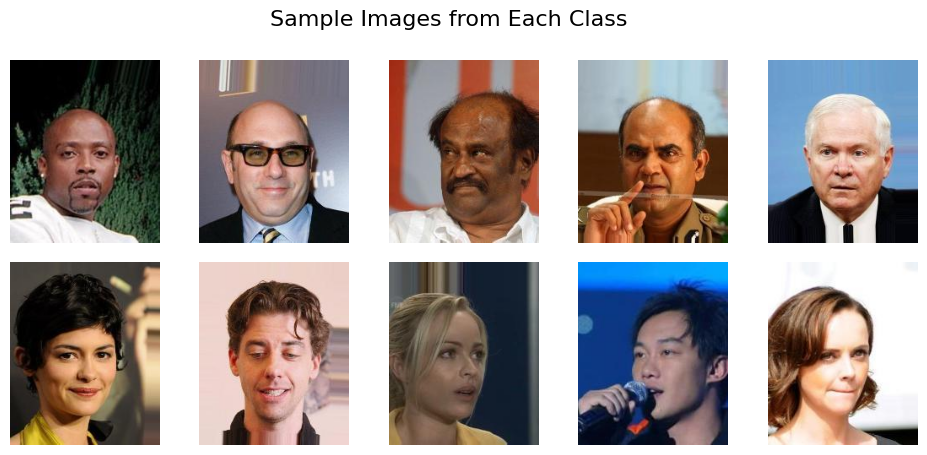

In [ ]:
# Visualize 5 images per class
n_samples = 5
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(2, n_samples, wspace=0.1, hspace=0.1)

for i, label in enumerate(LABELS):
    df_sample = (
        df_all.filter(F.col("label") == label)
        .orderBy(F.rand(seed=42))
        .limit(n_samples)
        .toPandas()
    )
    for j, (_, row) in enumerate(df_sample.iterrows()): 
        img_bytes = row["content"]
        img = Image.open(io.BytesIO(img_bytes))
        ax = fig.add_subplot(gs[i, j])
        ax.imshow(img)
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(label, fontsize=12, rotation=0, labelpad=40) 

plt.suptitle("Sample Images from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

From this visualization it's possible to see that some images are mislabeled, the "bald" man on the right is actually not bald.
This problem will be handled with outlier detection after extracting the numeric features.

# <font color='#2f94d7' size=6>**5. Undersampling**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

In [18]:
n_bald    = df_all.filter(F.col("label") == "Bald").count()
n_notbald = df_all.filter(F.col("label") == "NotBald").count()

# Bald is the minority class, so defining the target number of NotBald samples to be 2x the number of Bald samples
n_notbald_target = n_bald * 2

fraction = n_notbald_target / n_notbald

print(f"Bald (all of the minority class)    : {n_bald:,}")
print(f"NotBald (all of the majority class) : {n_notbald:,}")
print(f"NotBald target (2:1)         : {n_notbald_target:,}")
print(f"Fraction                     : {fraction:.4f}")  # fraction is the proportion of NotBald samples to keep to achieve the target ratio

df_notbald_sampled = (
    df_all
    .filter(F.col("label") == "NotBald")
    .sample(fraction=fraction, seed=42)
)

df_bald    = df_all.filter(F.col("label") == "Bald")
df_balanced = df_bald.union(df_notbald_sampled)

df_balanced.groupBy("label").count().orderBy("label").show()
print(f"Total após undersampling: {df_balanced.count():,}")

Bald (all of the minority class)    : 4,547
NotBald (all of the majority class) : 198,052
NotBald target (2:1)         : 9,094
Fraction                     : 0.0459


+-------+-----+
|  label|count|
+-------+-----+
|   Bald| 4547|
|NotBald| 9126|
+-------+-----+



Total após undersampling: 13,673


In [17]:
# Depois de teres df_features
# Calcular o centróide de cada classe
from pyspark.ml.stat import Summarizer

summarizer = Summarizer.mean(F.col("features"))

centroid_bald = df_features.filter(F.col("label") == "Bald") \
    .select(summarizer).first()[0]

centroid_notbald = df_features.filter(F.col("label") == "NotBald") \
    .select(summarizer).first()[0]

# Calcular distância de cada imagem Bald ao centróide Bald
# Imagens muito distantes são potenciais outliers/erros
from pyspark.ml.linalg import Vectors
from pyspark.sql.types import FloatType

@F.udf(FloatType())
def distance_to_centroid(features):
    return float(Vectors.squared_distance(features, centroid_bald))

df_bald_distances = (
    df_features
    .filter(F.col("label") == "Bald")
    .withColumn("dist_to_centroid", distance_to_centroid(F.col("features")))
)

# Ver as mais distantes — potenciais erros
df_bald_distances.orderBy(F.col("dist_to_centroid").desc()).show(20)

NameError: name 'df_features' is not defined